# Support Vector Machines (SVM)

Los Support Vector Machines (SVM) son modelos supervisados utilizados principalmente para tareas de clasificación. La idea central de un SVM es encontrar una frontera de decisión que separe las clases de la forma más robusta posible. En lugar de simplemente encontrar una línea que clasifique correctamente los datos, los SVM buscan maximizar el margen: la distancia entre las clases y la frontera de decisión.

In [115]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_wine
from sklearn.datasets import make_classification

plt.style.use("seaborn-v0_8")

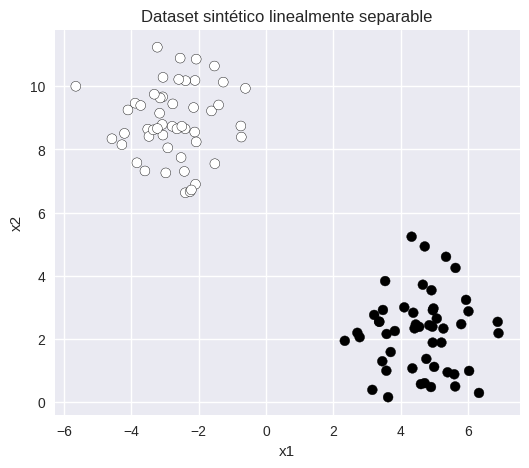

In [116]:
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k')
plt.title("Dataset sintético linealmente separable")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Los puntos más cercanos a la frontera de decisión reciben el nombre de Support Vectors. Estos puntos son especialmente importantes porque determinan la posición y orientación de la frontera. En muchos casos, mover uno de estos puntos puede cambiar completamente la solución encontrada por el modelo.

In [117]:
def plot_svm(model, X, y, ax=None, title="", plot_margin=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Check if the model is multiclass to use predict instead of decision_function for contourf
    if len(np.unique(y)) > 2:
        Z = model.predict(grid)
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.RdBu)
        # For multiclass, decision_function returns (n_samples, n_classes), so margins are not directly plottable in the same way.
        # We will not plot margins for multiclass as the current implementation does not support it.
        plot_margin = False # Disable margin plotting for multiclass for now
    else:
        Z = model.decision_function(grid)
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z > 0, alpha=0.2)

    ax.contour(xx, yy, Z, levels=[0], linewidths=2)

    if plot_margin:
        ax.contour(xx, yy, Z, levels=[-1, 1], linestyles='--', linewidths=1)

    ax.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolors='k')
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=220, facecolors='none', edgecolors='black', linewidths=1.5, label='Support vectors')

    ax.set_title(title)
    ax.legend()

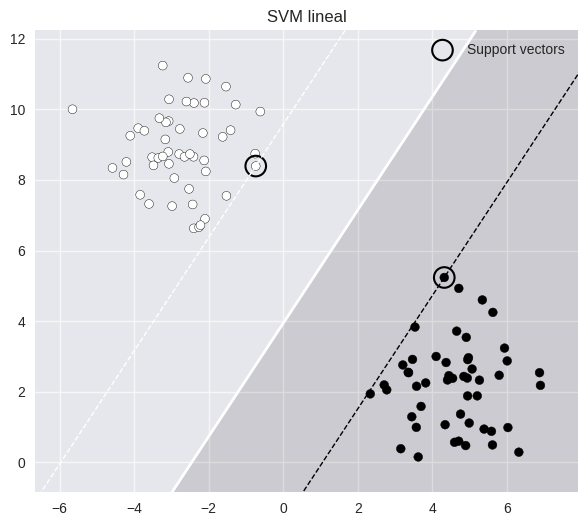

In [118]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X, y)

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(svm_linear, X, y, ax=ax, title="SVM lineal")
plt.show()

Notemos que el modelo encuentra una frontera que separa ambas clases, apoyándose para esta decisión en algunos puntos especialmente importantes para definir esa frontera: los support vectors.

En las siguientes secciones profundizaremos en cómo controlar el margen, cómo afectan los hiperparámetros al modelo, y cómo utilizar kernels para resolver problemas no lineales.

# Datos lineales y control del margen

En la sección anterior utilizamos un dataset sintético para introducir la idea de frontera de decisión y support vectors. Ahora trabajaremos con un dataset real para estudiar con más detalle el comportamiento de un SVM lineal.

## Dataset

Utilizaremos el dataset clásico de clasificación binaria Breast Cancer Wisconsin, cuyo objetivo es clasificar tumores como benignos o malignos. Para facilitar la visualización geométrica utilizaremos solamente dos variables.

In [119]:
data = load_breast_cancer()

X = data.data[:, [0, 1]]
y = data.target
feature_names = [data.feature_names[0], data.feature_names[1]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables utilizadas:")
print("-", feature_names[0])
print("-", feature_names[1])
print("\nShape:", X_scaled.shape)

Variables utilizadas:
- mean radius
- mean texture

Shape: (569, 2)


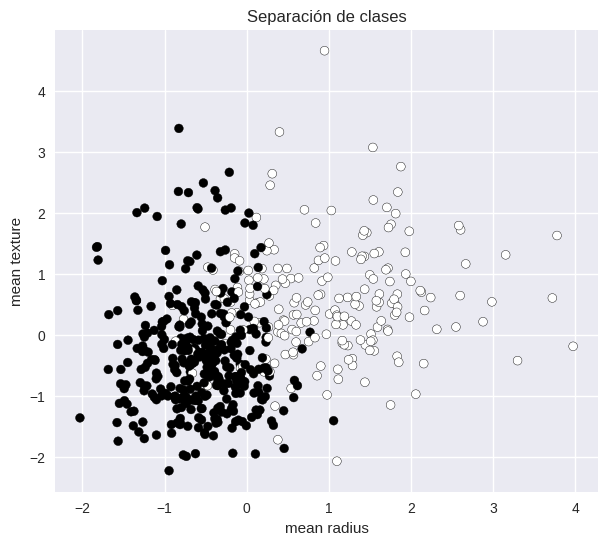

In [120]:
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=40, edgecolors='k')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Separación de clases")
plt.show()

## Métricas utilizadas

A lo largo del notebook utilizaremos algunas métricas simples para complementar la interpretación visual de los modelos. No obstante, al momento de aplicar conocimientos es posible implementar múltiples otras opciones ya aprendidas durante el curso.

Al mismo tiempo, cabe destacar que las métricas no reemplazan la interpretación visual. En SVM, la geometría de la frontera y el comportamiento del margen son igualmente importantes para comprender el modelo.

### Número de Support Vectors

Los support vectors son los puntos que definen la frontera de decisión del SVM. Observar cuántos support vectors utiliza el modelo puede ayudarnos a interpretar complejidad, regularización, sensibilidad a los datos, y posibles señales de sobreajuste.

### Accuracy



Corresponde a la proporción de predicciones correctas realizadas por el modelo. En este taller la utilizaremos como una referencia rápida del desempeño del clasificador.

$$Accuracy = \frac{\text{Predicciones correctas}}{\text{Total de predicciones}}$$



## SVM Lineal base

Entrenaremos primero un SVM lineal utilizando la configuración por defecto del modelo. Esto nos permitirá observar la frontera de decisión, el margen y los support vectors.

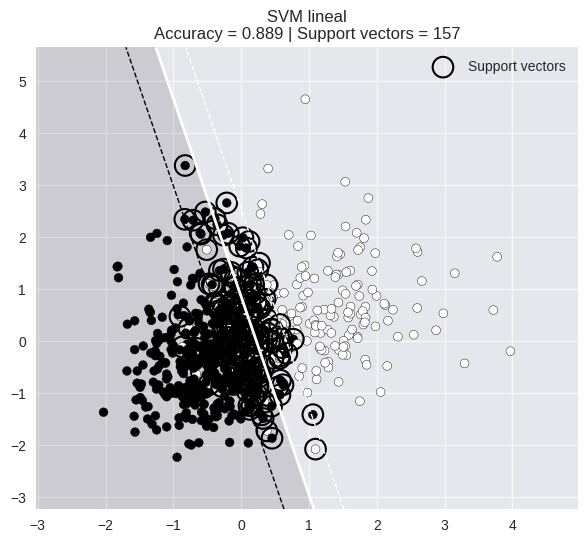

In [121]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_scaled, y)
y_pred = svm_linear.predict(X_scaled)

accuracy = accuracy_score(y, y_pred)
n_support = svm_linear.n_support_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(svm_linear, X_scaled, y, ax=ax, title=("SVM lineal\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"))
plt.show()

## Hiperparámetro `C`

El parámetro `C` controla cuánto penaliza el modelo los errores de clasificación. Existe un equilibrio entre maximizar el margen y clasificar correctamente los datos de entrenamiento.

Valores pequeños de `C` provocan mayor regularización, márgenes más amplios y mayor tolerancia a errores. Mientras que valores más grandes implican menor regularización, márgenes más estrechos y menor tolerancia a errores.

En términos prácticos, un `C` pequeño hace al modelo más suave, y un `C` grande hace al modelo más rígido.

### Exploración manual

Compararemos distintos valores de `C` para observar cómo cambian la frontera de decisión, el margen y los support vectors.

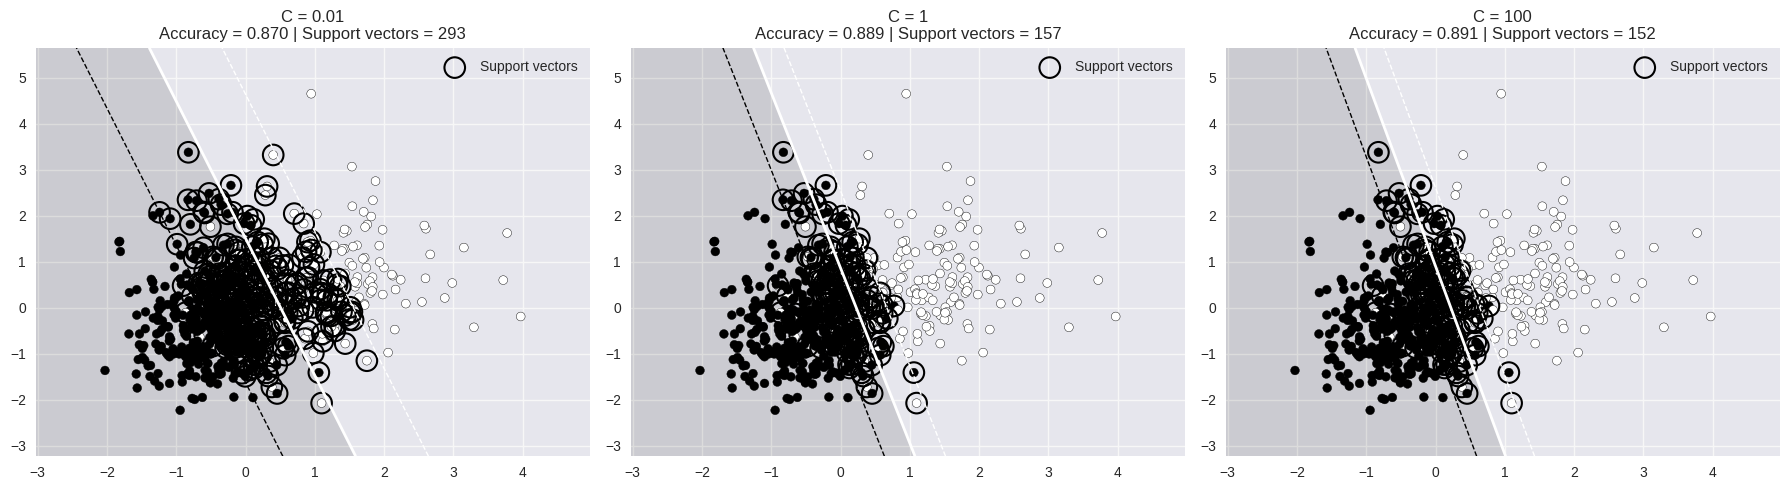

In [122]:
C_values = [0.01, 1, 100]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, C in zip(axes, C_values):

    model = SVC(kernel='linear', C=C)
    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)

    accuracy = accuracy_score(y, y_pred)
    n_support = model.n_support_.sum()

    plot_svm(model, X_scaled, y, ax=ax, title=(f"C = {C}\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"))

plt.tight_layout()
plt.show()

### Optimización del hiperparámetro C

Para encontrar el mejor valor para `C`, utilizaremos Grid Search.

In [123]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(estimator=SVC(kernel='linear'), param_grid=param_grid, cv=5)

grid.fit(X_scaled, y)

print("Mejor parámetro encontrado:")
print(grid.best_params_)

print("\nMejor score promedio (CV):")
print(round(grid.best_score_, 4))

Mejor parámetro encontrado:
{'C': 0.1}

Mejor score promedio (CV):
0.8805


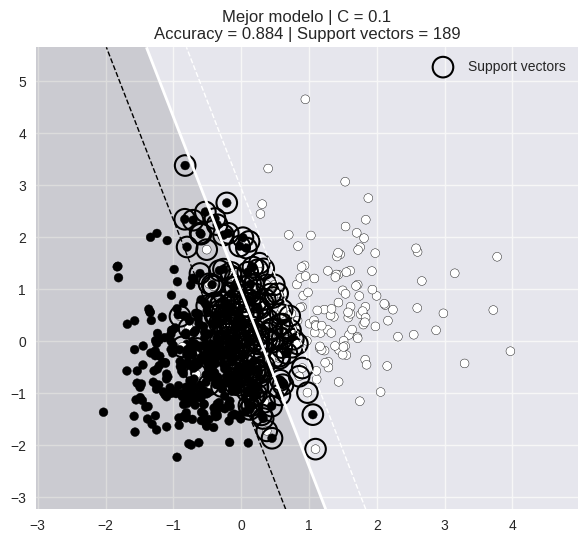

In [124]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_scaled)

accuracy = accuracy_score(y, y_pred)
n_support = best_model.n_support_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(best_model, X_scaled, y, ax=ax, title=(f"Mejor modelo | C = {grid.best_params_['C']}\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"))
plt.show()

# Datos no lineales y Kernel Trick

Hasta ahora trabajamos con fronteras lineales. Sin embargo, muchos problemas reales no pueden separarse utilizando una línea recta. En esta sección exploraremos datos no lineales, limitaciones de un SVM lineal, transformación del espacio de representación y la intuición detrás del kernel trick.

## Dataset

Generaremos un dataset sintético donde las clases no pueden separarse linealmente.

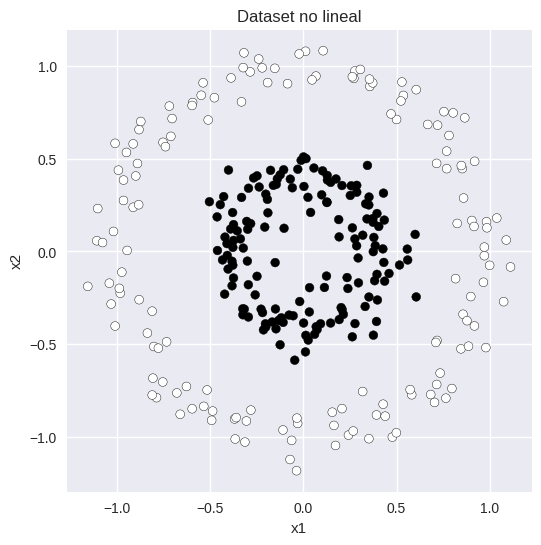

In [125]:
X_circles, y_circles = make_circles(n_samples=300, factor=0.4, noise=0.08, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, s=40, edgecolors='k')
plt.title("Dataset no lineal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## SVM lineal sobre datos no lineales

Intentemos utilizar un SVM lineal sobre este dataset. La pregunta que surge es:

> ¿Puede una línea separar correctamente ambas clases?

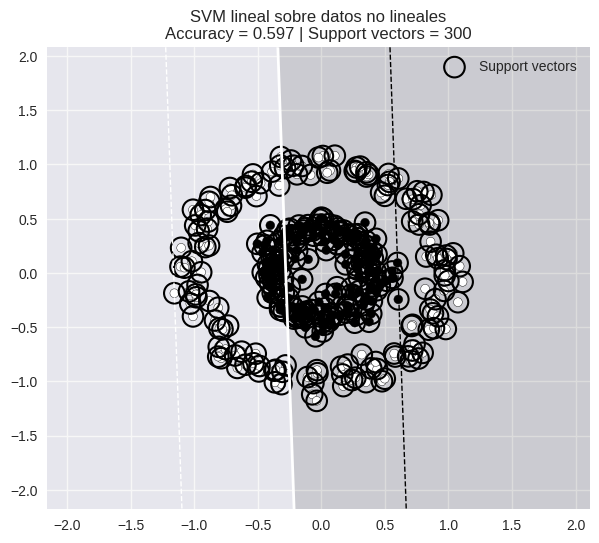

In [126]:
svm_linear_circles = SVC(kernel='linear', C=1.0)
svm_linear_circles.fit(X_circles, y_circles)
y_pred = svm_linear_circles.predict(X_circles)

accuracy = accuracy_score(y_circles, y_pred)
n_support = svm_linear_circles.n_support_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(svm_linear_circles, X_circles, y_circles, ax=ax, title=("SVM lineal sobre datos no lineales\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"))
plt.show()

El modelo lineal no logra construir una frontera adecuada para separar ambas clases. Esto ocurre porque las clases no son linealmente separables y una línea recta no es suficiente para resolver el problema. Entonces surge una idea importante:

> ¿Qué ocurriría si representamos los datos en otro espacio?

## Kernel Trick

La idea principal detrás del kernel trick es transformar los datos hacia un espacio de mayor dimensión donde la separación sea más simple. Los kernels permiten realizar esta transformación de manera discreta, sin calcular explícitamente todas las nuevas dimensiones.

En la práctica, entonces, el kernel trick consiste en usar una función kernel que compute similitudes como si esa transformación ya hubiese ocurrido. Para construir una intuición más clara, sin embargo, realizaremos una transformación explícita:

$$
z = x_1^2 + x_2^2
$$

Esto corresponde aproximadamente a utilizar la distancia al origen como una nueva dimensión. La idea es observar cómo un problema no lineal en 2D puede volverse separable en 3D.

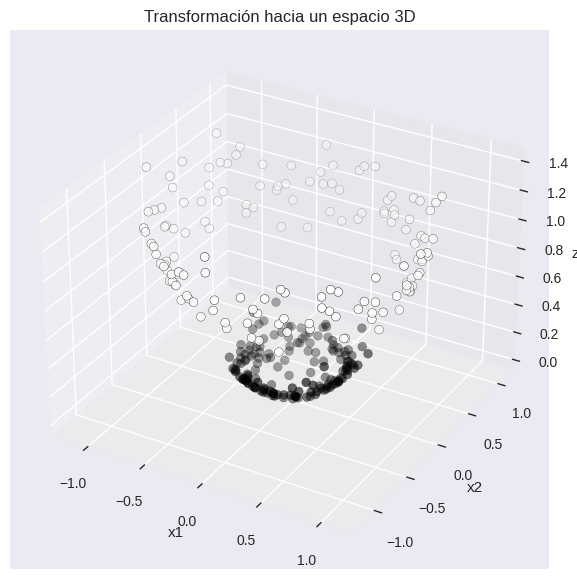

In [127]:
z = X_circles[:, 0]**2 + X_circles[:, 1]**2

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_circles[:, 0], X_circles[:, 1], z, c=y_circles, s=40, edgecolors='k')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("z")
ax.set_title("Transformación hacia un espacio 3D")
plt.show()

# Comparación de kernels

Ahora compararemos distintos tipos de kernels utilizando datasets sintéticos. El objetivo es observar cómo cambia la frontera de decisión según el kernel utilizado y desarrollar intuición sobre qué tipo de fronteras puede construir cada kernel, cuándo un kernel lineal deja de ser suficiente y cómo cambia la complejidad del modelo.


## Kernels comunes

Los kernels permiten modificar el espacio donde el SVM intenta separar los datos. En otras palabras, seleccionar un kernel equivale a seleccionar la geometría del espacio de representación.

### Kernel lineal



Construye fronteras lineales. Adecuado cuando los datos son aproximadamente separables linealmente, o el espacio original ya contiene suficiente información.



### Kernel polinomial



Permite construir fronteras curvas mediante combinaciones polinomiales de las variables. Su complejidad depende principalmente del parámetro `degree` y `coef0`. A medida que aumenta el grado del polinomio, la frontera puede volverse más compleja, aumentando también el riesgo de sobreajuste.


### Kernel RBF (Radial Basis Function)



Uno de los kernels más utilizados en la práctica. Permite construir fronteras altamente flexibles y locales. Su comportamiento depende especialmente del hiperparámetro `gamma`. Es especialmente útil cuando la relación entre clases es compleja o no existe una separación lineal clara que favorezca a otros algoritmos.

### Kernel sigmoidal

Construye fronteras basadas en una función sigmoidal. Tiene una formulación relacionada con ciertas neuronas artificiales y redes neuronales tempranas. Su comportamiento depende principalmente de `gamma` y `coef0`. Aunque es menos utilizado que RBF o polynomial, puede ser útil en algunos problemas específicos.

### Kernels personalizados

Además de los kernels predefinidos, ciertas implementaciones, como `SVC` (utilizada en este taller) permiten utilizar funciones kernel definidas por el usuario. Esto permite diseñar métricas de similitud específicas, incorporar conocimiento de dominio, o experimentar con nuevos kernels.

## Casos de ejemplo

Pondremos a prueba distintos kernels a través de diferentes datasets sintéticos con estructuras geométricas particulares.

In [128]:
kernels = [
    ('linear', 'Linear'),
    ('poly', 'Polynomial'),
    ('rbf', 'RBF'),
    ('sigmoid', 'Sigmoid')
]

### Dataset 1: Moons

Comenzaremos con un dataset moderadamente no lineal.

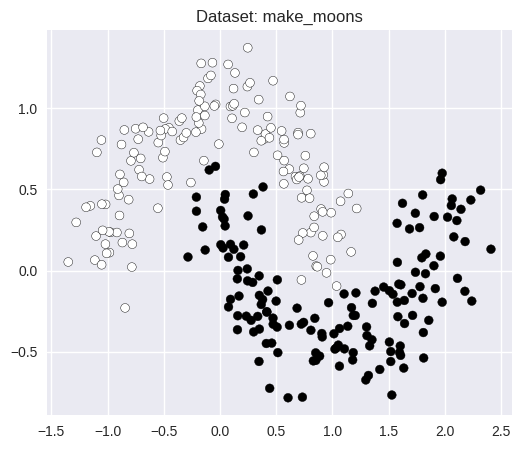

In [129]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=40, edgecolors='k')
plt.title("Dataset: make_moons")
plt.show()

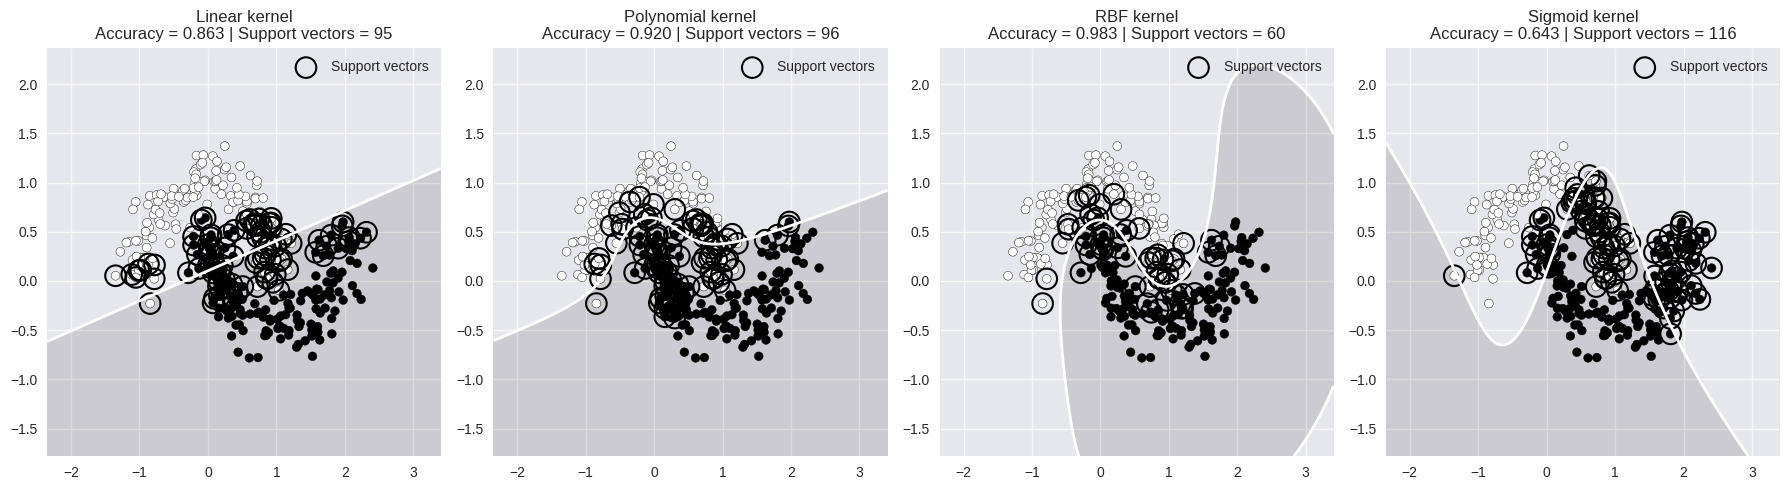

In [130]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (kernel, label) in zip(axes, kernels):

    model = SVC(kernel=kernel, degree=3, gamma='scale')
    model.fit(X_moons, y_moons)

    accuracy = model.score(X_moons, y_moons)
    n_support = model.n_support_.sum()

    plot_svm(model, X_moons, y_moons, ax=ax, title=(f"{label} kernel\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"), plot_margin=False)

plt.tight_layout()
plt.show()

### Dataset 2: Circles

Ahora utilizaremos un dataset con una estructura radial mucho más desafiante para modelos lineales.

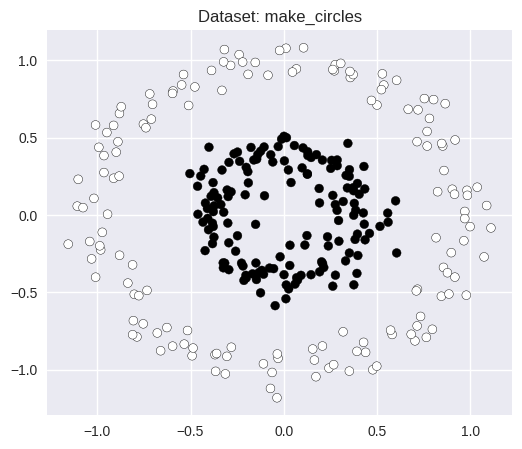

In [131]:
X_circles, y_circles = make_circles(n_samples=300, factor=0.4, noise=0.08, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, s=40, edgecolors='k')
plt.title("Dataset: make_circles")
plt.show()

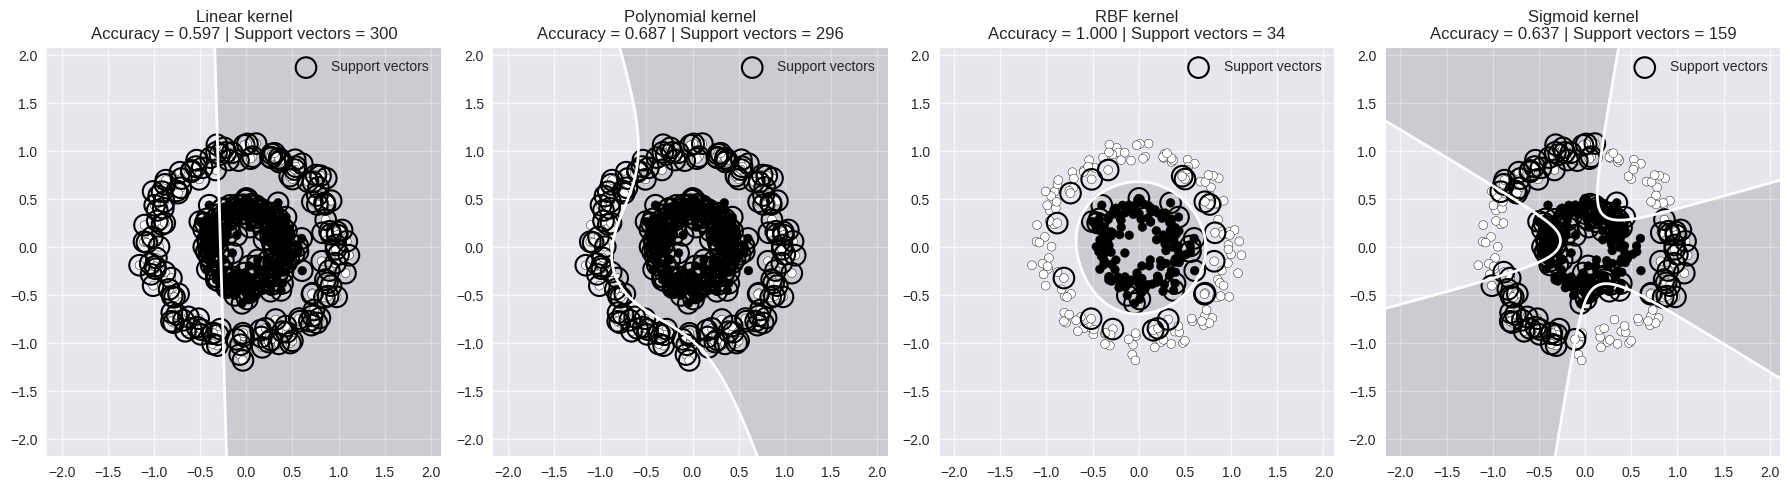

In [132]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (kernel, label) in zip(axes, kernels):

    model = SVC(kernel=kernel, degree=3, gamma='scale')
    model.fit(X_circles, y_circles)

    accuracy = model.score(X_circles, y_circles)
    n_support = model.n_support_.sum()

    plot_svm(model, X_circles, y_circles, ax=ax, title=(f"{label} kernel\n" f"Accuracy = {accuracy:.3f} | " f"Support vectors = {n_support}"), plot_margin=False)

plt.tight_layout()
plt.show()

# Ajuste de hiperparámetros

Hasta ahora utilizamos distintos kernels con configuraciones relativamente simples. Sin embargo, gran parte del rendimiento de un SVM depende de sus hiperparámetros.

En esta sección exploraremos cómo distintos parámetros modifican la complejidad del modelo, la forma de la frontera de decisión, la capacidad de generalización y el riesgo de sobreajuste.

Trabajaremos con datasets reales y haremos uso de la implementación de SVM incluida en `scikit-learn`, cuyo constructor toma la forma general:

```python
sklearn.svm.SVC(
    *,
    C=1.0,                           # Controla la regularización y el tamaño del margen
    kernel='rbf',                    # Tipo de kernel utilizado por el modelo
    degree=3,                        # Grado del polinomio (solo para kernel='poly')
    gamma='scale',                   # Controla el alcance de influencia de cada punto
    coef0=0.0,                       # Término independiente utilizado en kernels 'poly' y 'sigmoid'
    shrinking=True,                  # Utiliza una heurística de optimización para acelerar el entrenamiento
    probability=False,               # Habilita estimación de probabilidades (más costoso computacionalmente)
    tol=0.001,                       # Tolerancia utilizada como criterio de convergencia
    cache_size=200,                  # Tamaño de caché utilizado por el algoritmo (en MB)
    class_weight=None,               # Permite asignar pesos distintos a cada clase
    verbose=False,                   # Muestra información detallada durante el entrenamiento
    max_iter=-1,                     # Número máximo de iteraciones (-1 = sin límite)
    decision_function_shape='ovr',   # Estrategia para clasificación multiclase
    break_ties=False,                # Rompe empates en clasificación multiclase
    random_state=None                # Semilla aleatoria para reproducibilidad
)
```

En este taller, sin embargo, nos concentraremos principalmente en `kernel`, `C`, `gamma`, `degree`, `coef0` y `class_weight`, ya que son los parámetros con mayor impacto sobre la frontera de decisión y el comportamiento del modelo.

Para más detalles, puedes revisar la documentación: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

## Principales hiperparámetros

### `C`


Controla la regularización del modelo. Es decir, cuánto penaliza el modelo los errores de clasificación. Su ajuste implica encontrar un equilibrio entre maximizar el margen y clasificar correctamente los datos de entrenamiento.

Valores pequeños de `C` provocan mayor regularización, márgenes más amplios y mayor tolerancia a errores, creando un modelo más suave. Mientras que valores más grandes implican menor regularización, márgenes más estrechos y menor tolerancia a errores, permitiendo el desarrollo de un sistema más rígido.

### `gamma`

Utilizado principalmente en kernels no lineales como `rbf`, `poly` y `sigmoid`. Controla el alcance de influencia de cada punto.

Un `gamma` pequeño permite una influencia más amplia y con ello genera fronteras suaves. Un `gamma` grande, por otro lado, potencia influencia local, permitiendo obtener fronteras más complejas pero también aumentado el riesgo de sobreajuste.

Dado que `gamma` controla la influencia espacial de los puntos, su uso solo tiene sentido kernels que usan distancias o similitudes no lineales. Por ello, su ajuste en modelos lineales no es necesario.



### `degree`

Hiperparámetro específico de kernels polinomiales. Controla el grado del polinomio utilizado para construir la frontera.

En grados pequeños, genera fronteras simples. En grados altos, fronteras más complejas.

### `coef0`

Utilizado principalmente en kernels `poly` y `sigmoid`. Controla el peso relativo de términos de orden superior en la función kernel.

En términos prácticos, valores bajos acercan el comportamiento del modelo a uno lineal, mientras que valores altos producen fronteras más influenciadas por términos no lineales.


### `class_weight`

Permite ajustar la importancia relativa de cada clase. Es transversal al tipo de kernel (al igual que `C`), y es especialmente útil cuando el dataset está desbalanceado.

La opción más común es asumir que el dataset se encuentra balanceado:

```python
class_weight='balanced'

## Caso 1: Wine Dataset

Utilizaremos el dataset Wine incluido en `scikit-learn`. El objetivo consiste en clasificar distintos tipos de vino a partir de propiedades químicas. Usaremos dos enfoques complementarios:

**Visualización:** Usaremos dos variables para poder observar fronteras de decisión claramente como lo hemos hecho hasta ahora, comparar kernels e interpretar hiperparámetros geométricamente. Este paso permite desarrollar intuición sobre el problema y su geometría, pero no es suficiente por sí solo para tomar decisiones, pues limitar el número de variables implica pasar por alto mucha de la información que pueda estar contenida en el resto del conjunto de datos.

**Evaluación:** Usaremos todas las variables para trabajar sobre un problema más realista, evaluar generalización, y utilizar Grid Search de forma más significativa en el ajuste de hiperparámetros considerando las propiedades inherentes al conjunto de datos.

In [133]:
wine = load_wine()
X_full = wine.data
y = wine.target

print("Shape del dataset:")
print(X_full.shape)
print("\nClases:")
print(wine.target_names)

Shape del dataset:
(178, 13)

Clases:
['class_0' 'class_1' 'class_2']


### Visualización

Las visualizaciones 2D son extremadamente útiles para desarrollar intuición, pero no representan completamente el comportamiento de un modelo en espacios multidimensionales.

Por lo tanto, debemos evitar sobreinterpretar la geometría observada en 2D, especialmente cuando el modelo final utiliza muchas variables simultáneamente.

#### Selección de variables

In [134]:
X_vis = X_full[:, [0, 9]]
feature_names = [wine.feature_names[0], wine.feature_names[9]]

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

print("Variables utilizadas:")
print("-", feature_names[0])
print("-", feature_names[1])

Variables utilizadas:
- alcohol
- color_intensity


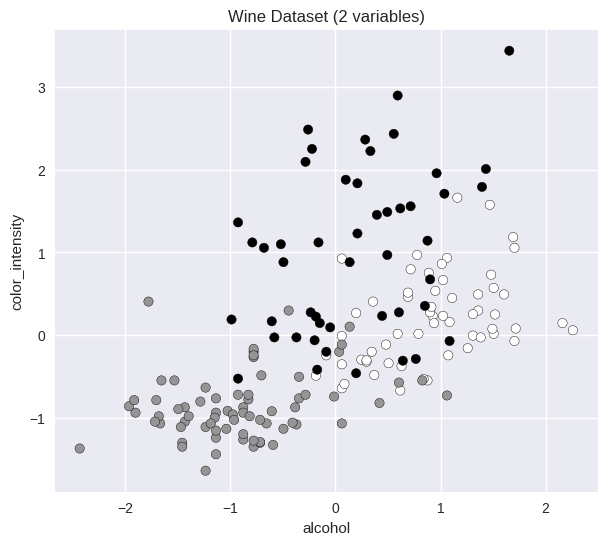

In [135]:
plt.figure(figsize=(7, 6))
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y, s=45, edgecolors='k')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Wine Dataset (2 variables)")
plt.show()

#### Comparación preliminar de kernels

In [136]:
configs = [
    {
        'kernel': 'linear',
        'C': 1
    },
    {
        'kernel': 'poly',
        'C': 1,
        'degree': 3,
        'coef0': 1
    },
    {
        'kernel': 'rbf',
        'C': 1,
        'gamma': 'scale'
    },
    {
        'kernel': 'sigmoid',
        'C': 1,
        'gamma': 'scale',
        'coef0': 1
    }
]

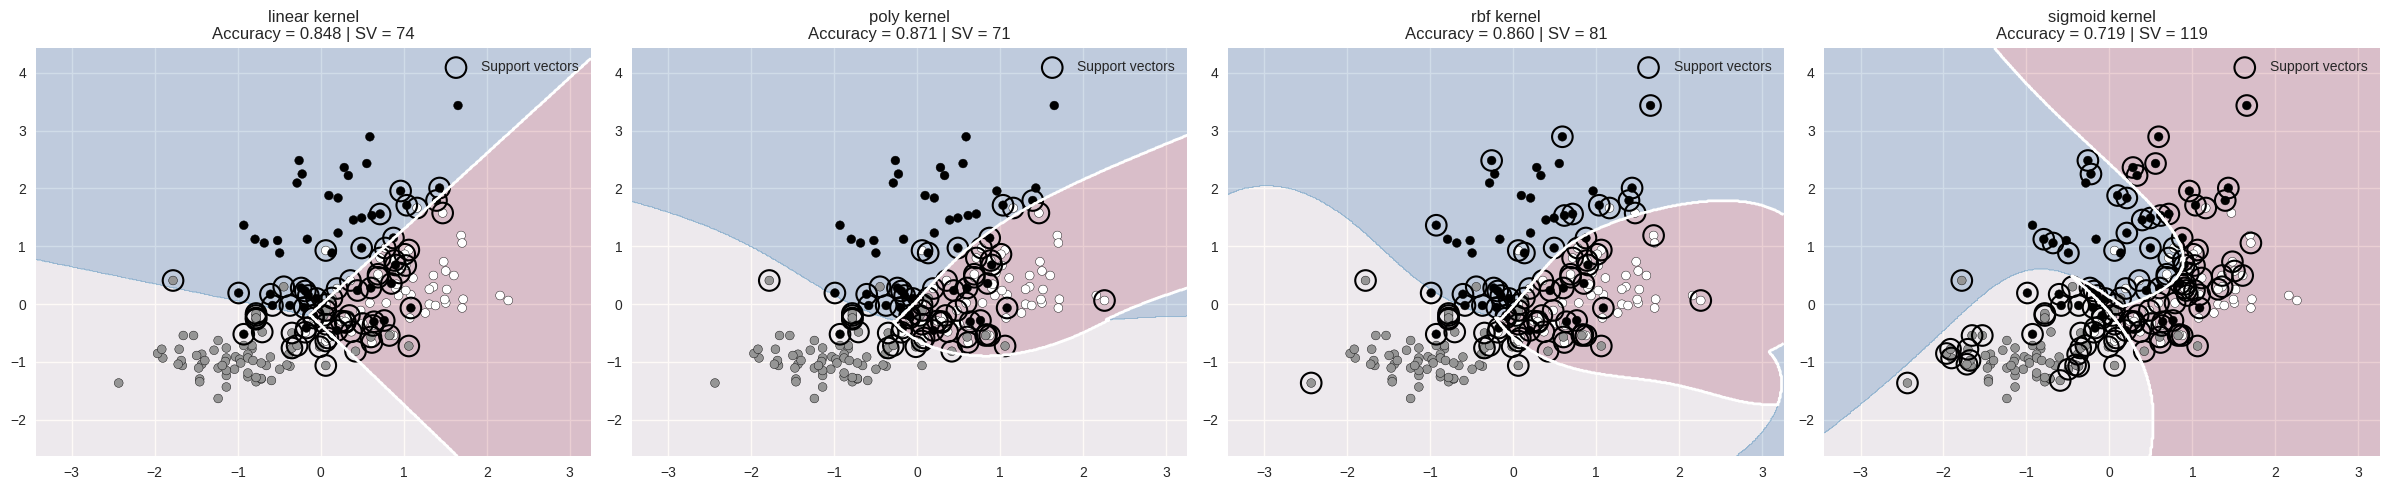

In [137]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, config in zip(axes, configs):

    model = SVC(**config)
    model.fit(X_vis_scaled, y)

    accuracy = model.score(X_vis_scaled, y)
    n_support = model.n_support_.sum()

    plot_svm(model, X_vis_scaled, y, ax=ax, title=(f"{config['kernel']} kernel\n" f"Accuracy = {accuracy:.3f} | " f"SV = {n_support}"), plot_margin=False)

plt.tight_layout()
plt.show()

##### Actividad 1

Observa cuidadosamente la complejidad de las fronteras, el número de support vectors, las regiones difíciles de clasificar y las diferencias entre kernels. Con base en estas observaciones, responde:

1. ¿Qué kernels parecen demasiado rígidos?
2. ¿Qué kernels parecen excesivamente complejos?
3. ¿Qué configuraciones parecen más razonables?
4. ¿Qué kernel escogerías preliminarmente?
5. ¿Cómo podría esta conclusión cambiar utilizando las 13 variables?

Puedes ajustar ligeramente las configuraciones iniciales para un mejor estudio.

#### Exploración del hiperparámetro `gamma`

Estudiaremos brevemente cómo `gamma` modifica la frontera de decisión en un kernel RBF.

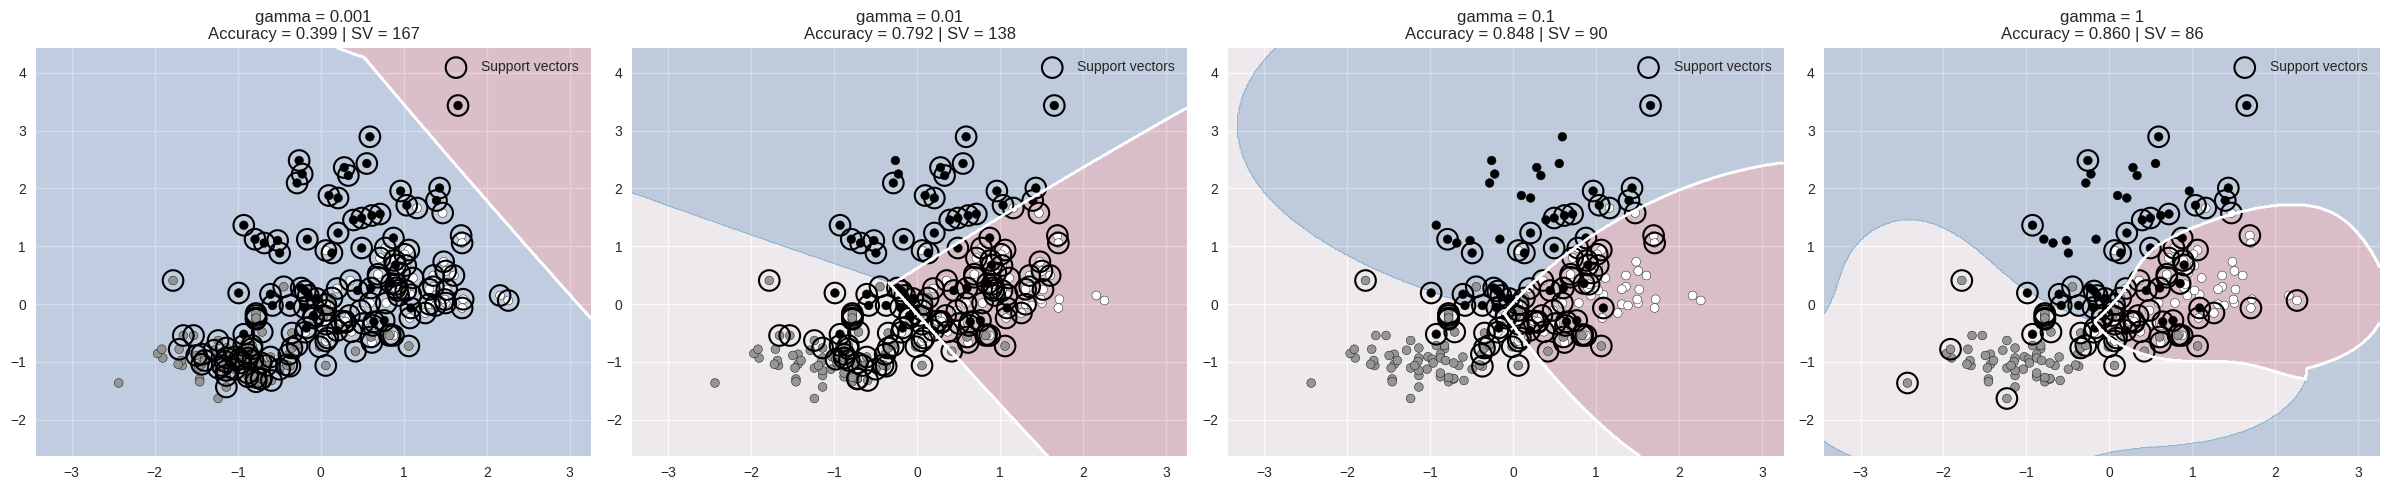

In [138]:
gamma_values = [0.001, 0.01, 0.1, 1]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, gamma in zip(axes, gamma_values):

    model = SVC(kernel='rbf', C=1, gamma=gamma)
    model.fit(X_vis_scaled, y)

    accuracy = model.score(X_vis_scaled, y)
    n_support = model.n_support_.sum()

    plot_svm(model, X_vis_scaled, y, ax=ax, title=(f"gamma = {gamma}\n" f"Accuracy = {accuracy:.3f} | " f"SV = {n_support}"), plot_margin=False)

plt.tight_layout()
plt.show()

##### Actividad 2

Responde:

1. ¿Qué ocurre cuando `gamma` aumenta?
2. ¿Qué fronteras parecen más suaves?
3. ¿Qué configuraciones parecen sobreajustar?
4. ¿Existe relación entre la complejidad visual de la frontera y su rendimiento?

### Evaluación

Hasta ahora utilizamos únicamente dos variables para desarrollar intuición geométrica. Ahora trabajaremos utilizando todas las variables del dataset para un estudio más realista. Es importante destacar que la geometría observada en 2D puede orientar hipótesis iniciales, pero no determina automáticamente qué configuraciones serán las mejores para el modelo final.

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (142, 13)
Test shape: (36, 13)


#### Comparación inicial de kernels

In [140]:
configs = [
    {
        'kernel': 'linear',
        'C': 1
    },
    {
        'kernel': 'poly',
        'C': 1,
        'degree': 3,
        'coef0': 1
    },
    {
        'kernel': 'rbf',
        'C': 1,
        'gamma': 'scale'
    },
    {
        'kernel': 'sigmoid',
        'C': 1,
        'gamma': 'scale',
        'coef0': 1
    }
]

In [141]:
for config in configs:

    model = SVC(**config)
    model.fit(X_train_scaled, y_train)

    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    n_support = model.n_support_.sum()

    print("=" * 60)
    print(config)
    print("\nTrain accuracy:", round(train_score, 4))
    print("Test accuracy:", round(test_score, 4))
    print("Support vectors:", n_support)

print("=" * 60)

{'kernel': 'linear', 'C': 1}

Train accuracy: 1.0
Test accuracy: 0.9444
Support vectors: 27
{'kernel': 'poly', 'C': 1, 'degree': 3, 'coef0': 1}

Train accuracy: 1.0
Test accuracy: 0.9444
Support vectors: 39
{'kernel': 'rbf', 'C': 1, 'gamma': 'scale'}

Train accuracy: 0.993
Test accuracy: 0.9722
Support vectors: 61
{'kernel': 'sigmoid', 'C': 1, 'gamma': 'scale', 'coef0': 1}

Train accuracy: 0.9296
Test accuracy: 0.9722
Support vectors: 72


Accuracy es útil, pero no siempre suficiente. Por ello, ahora incorporaremos reporte de clasificación y matriz de confusión.

En la siguiente celda puedes modificar manualmente el kernel e hiperparámetros `C`, `gamma`, `degree` y `coef0` a modo de exploración para encontrar relaciones entre estos elementos y el rendimiento del modelo.

In [142]:
model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



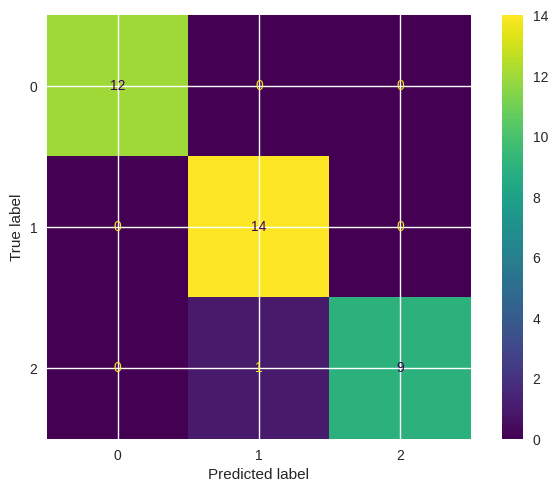

In [143]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

#### Optimización de hiperparámetros por Grid Search

La siguiente celda ofrece una base sobre la cual aplicar Grid Search. Puedes usar los experimentos anteriores para ajustar los datos de la malla y encontrar un modelo más óptimo.

In [144]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'coef0': [0, 1]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.001, 0.01, 0.1]
    },
    {
        'kernel': ['sigmoid'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.001, 0.01, 0.1],
        'coef0': [0, 1]
    }
]

In [145]:
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Mejor configuración:")
print(grid.best_params_)
print("\nMejor score CV:")
print(round(grid.best_score_, 4))

Mejor configuración:
{'C': 0.1, 'coef0': 1, 'degree': 3, 'kernel': 'poly'}

Mejor score CV:
1.0


Train accuracy: 1.0
Test accuracy: 1.0
Support vectors: 56

Best params:
{'C': 0.1, 'coef0': 1, 'degree': 3, 'kernel': 'poly'}

Classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



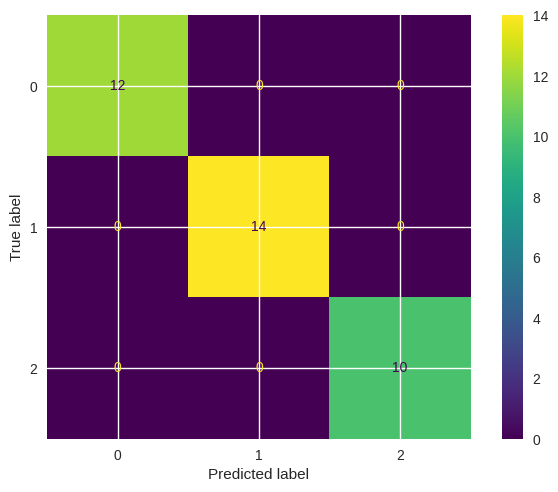

In [146]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

train_score = best_model.score(X_train_scaled, y_train)
test_score = best_model.score(X_test_scaled, y_test)
n_support = best_model.n_support_.sum()

print("Train accuracy:", round(train_score, 4))
print("Test accuracy:", round(test_score, 4))
print("Support vectors:", n_support)

print("\nBest params:")
print(grid.best_params_)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

## Caso 2: Synthetic Classification Dataset

En el caso anterior trabajamos con un dataset relativamente sencillo y altamente separable. Ahora utilizaremos un problema más complejo, donde distintos kernels pueden comportarse de manera muy diferente, los hiperparámetros tendrán un impacto más importante y el refinamiento iterativo de Grid Search será mucho más útil.

En este caso utilizaremos un dataset generado artificialmente mediante `make_classification` de `scikit-learn`. El dataset será construido deliberadamente para introducir ruido, solapamiento entre clases, variables irrelevantes y estructuras más difíciles de modelar.

A diferencia del caso anterior omitiremos visualización 2D y trabajaremos directamente sobre el espacio completo de variables. En esta sección el foco estará en comparación de modelos, evaluación, detección de sobreajuste y refinamiento iterativo de hiperparámetros.



In [147]:
X, y = make_classification(n_samples=2500, n_features=40, n_informative=8, n_redundant=8, n_repeated=0, n_classes=2, n_clusters_per_class=3, class_sep=0.6, flip_y=0.08, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain shape:")
print(X_train_scaled.shape)
print("Test shape:")
print(X_test_scaled.shape)


Train shape:
(2000, 40)
Test shape:
(500, 40)


#### Modelo baseline

Comenzaremos con un modelo relativamente estándar utilizando kernel RBF e hiperparámetros por defecto. Buscamos construir una referencia inicial antes de optimizar.

In [148]:
baseline_model = SVC(kernel='rbf')
baseline_model.fit(X_train_scaled, y_train)

train_score = baseline_model.score(X_train_scaled, y_train)
test_score = baseline_model.score(X_test_scaled, y_test)

print("Train accuracy:", round(train_score, 4))
print("Test accuracy:", round(test_score, 4))
print("Support vectors:", baseline_model.n_support_.sum())

Train accuracy: 0.9035
Test accuracy: 0.732
Support vectors: 1532


              precision    recall  f1-score   support

           0       0.76      0.67      0.71       250
           1       0.71      0.79      0.75       250

    accuracy                           0.73       500
   macro avg       0.74      0.73      0.73       500
weighted avg       0.74      0.73      0.73       500



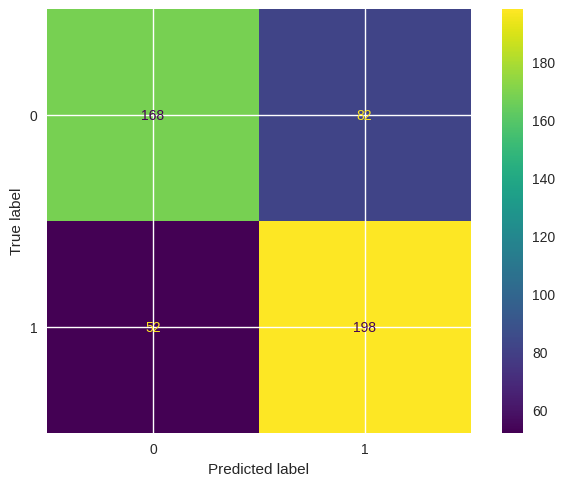

In [149]:
y_pred = baseline_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

##### Actividad 3

Interpreta el baseline y responde:

1. ¿Los resultados parecen razonables?
2. ¿Existe diferencia importante entre train y test accuracy?
3. ¿Qué tipo de errores parecen más relevantes?
4. ¿Crees que el modelo podría mejorar cambiando el kernel o ajustando hiperparámetros?
5. ¿Qué hiperparámetros esperas que sean más importantes?

#### Optimización de hiperparámetros

Realizaremos una primera búsqueda de hiperparámetros con Grid Search. Esto permite identificar kernels prometedores, descartar configuraciones pobres y detectar regiones interesantes del espacio de hiperparámetros.

In [150]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'coef0': [0, 1]
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': ['scale', 0.001, 0.01, 0.1]
    },
    {
        'kernel': ['sigmoid'],
        'C': [0.01, 0.1, 1, 10],
        'gamma': ['scale', 0.001, 0.01, 0.1],
        'coef0': [0, 1]
    }
]

In [151]:
grid_1 = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=5)
grid_1.fit(X_train_scaled, y_train)

print("Best params:")
print(grid_1.best_params_)

print("\nBest CV score:")
print(round(grid_1.best_score_, 4))

Best params:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best CV score:
0.7485


Train accuracy: 0.9035
Test accuracy: 0.732
Support vectors: 1532

Best params:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Classification report:

              precision    recall  f1-score   support

           0       0.76      0.67      0.71       250
           1       0.71      0.79      0.75       250

    accuracy                           0.73       500
   macro avg       0.74      0.73      0.73       500
weighted avg       0.74      0.73      0.73       500



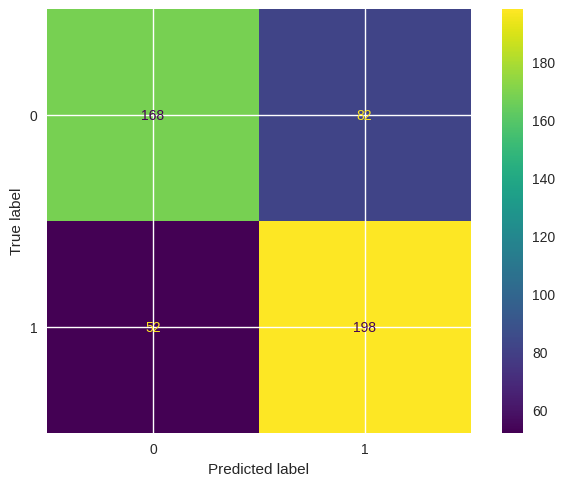

In [152]:
best_model_1 = grid_1.best_estimator_
y_pred = best_model_1.predict(X_test_scaled)

train_score = best_model_1.score(X_train_scaled, y_train)
test_score = best_model_1.score(X_test_scaled, y_test)

print("Train accuracy:", round(train_score, 4))
print("Test accuracy:", round(test_score, 4))
print("Support vectors:", best_model_1.n_support_.sum())

print("\nBest params:")
print(grid_1.best_params_)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

#### Refinamiento de hiperparámetros

Grid Search suele realizarse de forma iterativa. La primera búsqueda amplia permite identificar regiones prometedoras. Luego, refinamos la búsqueda explorando valores cercanos a los mejores resultados encontrados.

##### Actividad 4

A partir de los resultados obtenidos de la primera búsqueda:

1. Construye una nueva malla de hiperparámetros.
2. Refina la búsqueda alrededor de los mejores valores encontrados.
3. Compara train accuracy, test accuracy, CV score, matriz de confusión y número de support vectors.
4. Evalúa si el nuevo modelo realmente mejora la generalización o en su lugar amenaza con sobreajustar.
5. Redacta observaciones respecto al impacto de los hiperparámetros y diferencias entre los modelos.